# Análisis Exploratorio de Datos (EDA)

**Objetivo:** Comprender la estructura, distribución y comportamiento temporal de las series de precios de materias primas (X, Y, Z) y equipos (Equipo1, Equipo2).

**Datos:** `historico_equipos.csv` — 3,530 registros diarios (2010-01-04 a 2023-08-31)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from src.data_loader import build_analysis_dataset, build_extended_series

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

RESULTS_DIR = '../results/figures'
import os; os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Carga de datos

In [16]:
df = build_analysis_dataset()
print(df.info())
print(f"Registros: {df.shape[0]}")
print(f"Periodo  : {df['Date'].min().date()} a {df['Date'].max().date()}")
print(f"Duplicados: {df.duplicated().sum()}")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3530 entries, 0 to 3529
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           3530 non-null   datetime64[us]
 1   Price_X        3530 non-null   float64       
 2   Price_Y        3530 non-null   float64       
 3   Price_Z        3530 non-null   float64       
 4   Price_Equipo1  3530 non-null   float64       
 5   Price_Equipo2  3530 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 165.6 KB
None
Registros: 3530
Periodo  : 2010-01-04 a 2023-08-31
Duplicados: 0


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


In [6]:
df.describe().round(2)

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
count,3530,3530.00,3530.00,3530.00,3530.00,3530.00
mean,2016-10-31 13:29:20.226629,78.09,555.53,2037.43,460.04,889.98
min,2010-01-04 00:00:00,19.33,257.50,1421.50,208.34,566.00
25%,2013-06-03 06:00:00,57.05,482.50,1767.25,398.23,777.70
50%,2016-10-31 12:00:00,75.40,541.62,1974.75,451.25,869.78
75%,2020-04-01 18:00:00,104.58,620.00,2235.94,515.61,979.12
max,2023-08-31 00:00:00,127.98,1062.37,3984.00,855.32,1703.96
std,NaN,25.19,138.49,373.14,113.68,170.04


In [7]:
# Verificar frecuencia: datos de lunes a viernes (días hábiles)
df['weekday'] = df['Date'].dt.day_name()
print("Distribución por día de la semana:")
print(df['weekday'].value_counts())
df = df.drop(columns='weekday')

Distribución por día de la semana:
weekday
Thursday     711
Wednesday    710
Tuesday      709
Monday       706
Friday       694
Name: count, dtype: int64


## 1.2 Verificación de fechas faltantes

Sin valores nulos **no implica** sin fechas faltantes. Puede haber días hábiles
donde el registro directamente no existe en el dataset (fila ausente).
Esto es relevante porque ARIMA asume observaciones igualmente espaciadas.

In [18]:
# Rango completo de días hábiles esperados entre la primera y última fecha
bdays_expected = pd.bdate_range(start=df["Date"].min(), end=df["Date"].max())
bdays_actual = pd.DatetimeIndex(df["Date"])

missing_dates = bdays_expected.difference(bdays_actual)
extra_dates   = bdays_actual.difference(bdays_expected)  # días no hábiles incluidos

print(f"Días hábiles esperados (lun-vie): {len(bdays_expected):,}")
print(f"Registros en el dataset         : {len(df):,}")
print(f"Diferencia                       : {len(df) - len(bdays_expected):+,}")
print()
print(f"Fechas hábiles FALTANTES en el dataset : {len(missing_dates)}")
print(f"Fechas EXTRA (no eran día hábil)       : {len(extra_dates)}")

if len(missing_dates) > 0:
    print("Primeras fechas faltantes:")
    print(missing_dates[:10].date)

if len(extra_dates) > 0:
    print("Fechas extra (probablemente festivos de otro mercado):")
    print(extra_dates[:10].date)
    print(f"Día de semana de las fechas extra: {pd.Series(extra_dates).dt.day_name().value_counts().to_dict()}")


Días hábiles esperados (lun-vie): 3,564
Registros en el dataset         : 3,530
Diferencia                       : -34

Fechas hábiles FALTANTES en el dataset : 34
Fechas EXTRA (no eran día hábil)       : 0
Primeras fechas faltantes:
[datetime.date(2010, 4, 2) datetime.date(2011, 4, 22)
 datetime.date(2011, 12, 26) datetime.date(2012, 1, 2)
 datetime.date(2012, 4, 6) datetime.date(2012, 12, 25)
 datetime.date(2013, 1, 1) datetime.date(2013, 3, 29)
 datetime.date(2013, 12, 25) datetime.date(2014, 4, 18)]


In [19]:
import holidays

# Festivos de Colombia para el rango de años del dataset
co_holidays = holidays.Colombia(years=range(2010, 2024))

# Cruzar fechas faltantes con festivos colombianos
missing_dates = pd.bdate_range(start=df["Date"].min(), end=df["Date"].max()).difference(df["Date"])

rows = []
for date in missing_dates:
    fecha = date.date()
    nombre = co_holidays.get(fecha)  # None si no es festivo colombiano
    rows.append({
        "Fecha": fecha,
        "Dia semana": date.day_name(),
        "Festivo Colombia": nombre if nombre else "NO identificado",
        "Es festivo CO": nombre is not None,
    })

missing_df = pd.DataFrame(rows)

n_festivos = missing_df["Es festivo CO"].sum()
n_no_identificados = (~missing_df["Es festivo CO"]).sum()

print(f"Fechas faltantes explicadas por festivos colombianos : {n_festivos} / {len(missing_df)}")
print(f"Fechas faltantes NO identificadas como festivo CO    : {n_no_identificados}")
print()

# Mostrar tabla completa
missing_df["Festivo Colombia"] = missing_df["Festivo Colombia"].str[:45]  # truncar nombres largos
print(missing_df.to_string(index=False))


Fechas faltantes explicadas por festivos colombianos : 29 / 34
Fechas faltantes NO identificadas como festivo CO    : 5

     Fecha Dia semana Festivo Colombia  Es festivo CO
2010-04-02     Friday    Viernes Santo           True
2011-04-22     Friday    Viernes Santo           True
2011-12-26     Monday  NO identificado          False
2012-01-02     Monday  NO identificado          False
2012-04-06     Friday    Viernes Santo           True
2012-12-25    Tuesday          Navidad           True
2013-01-01    Tuesday        Año Nuevo           True
2013-03-29     Friday    Viernes Santo           True
2013-12-25  Wednesday          Navidad           True
2014-04-18     Friday    Viernes Santo           True
2014-12-25   Thursday          Navidad           True
2015-01-01   Thursday        Año Nuevo           True
2015-04-03     Friday    Viernes Santo           True
2015-12-25     Friday          Navidad           True
2016-01-01     Friday        Año Nuevo           True
2016-03-25     

In [20]:
missing_df[missing_df['Es festivo CO'] == False]

,Fecha,Dia semana,Festivo Colombia,Es festivo CO
2,2011-12-26,Monday,NO identificado,False
3,2012-01-02,Monday,NO identificado,False
16,2016-12-26,Monday,NO identificado,False
31,2022-12-26,Monday,NO identificado,False
32,2023-01-02,Monday,NO identificado,False


Las fechas que no aparecen y tampoco califican como festivos, parece tener sentido ya que son fechas cercanas a las fiestas decembrinas, 25 de diciembre cayo domingo, lo mas probable es que el mercado no estuviera disponible el 26, al igual que con el 02 de entro

## 2.Comportamiento general de las series de tiempo

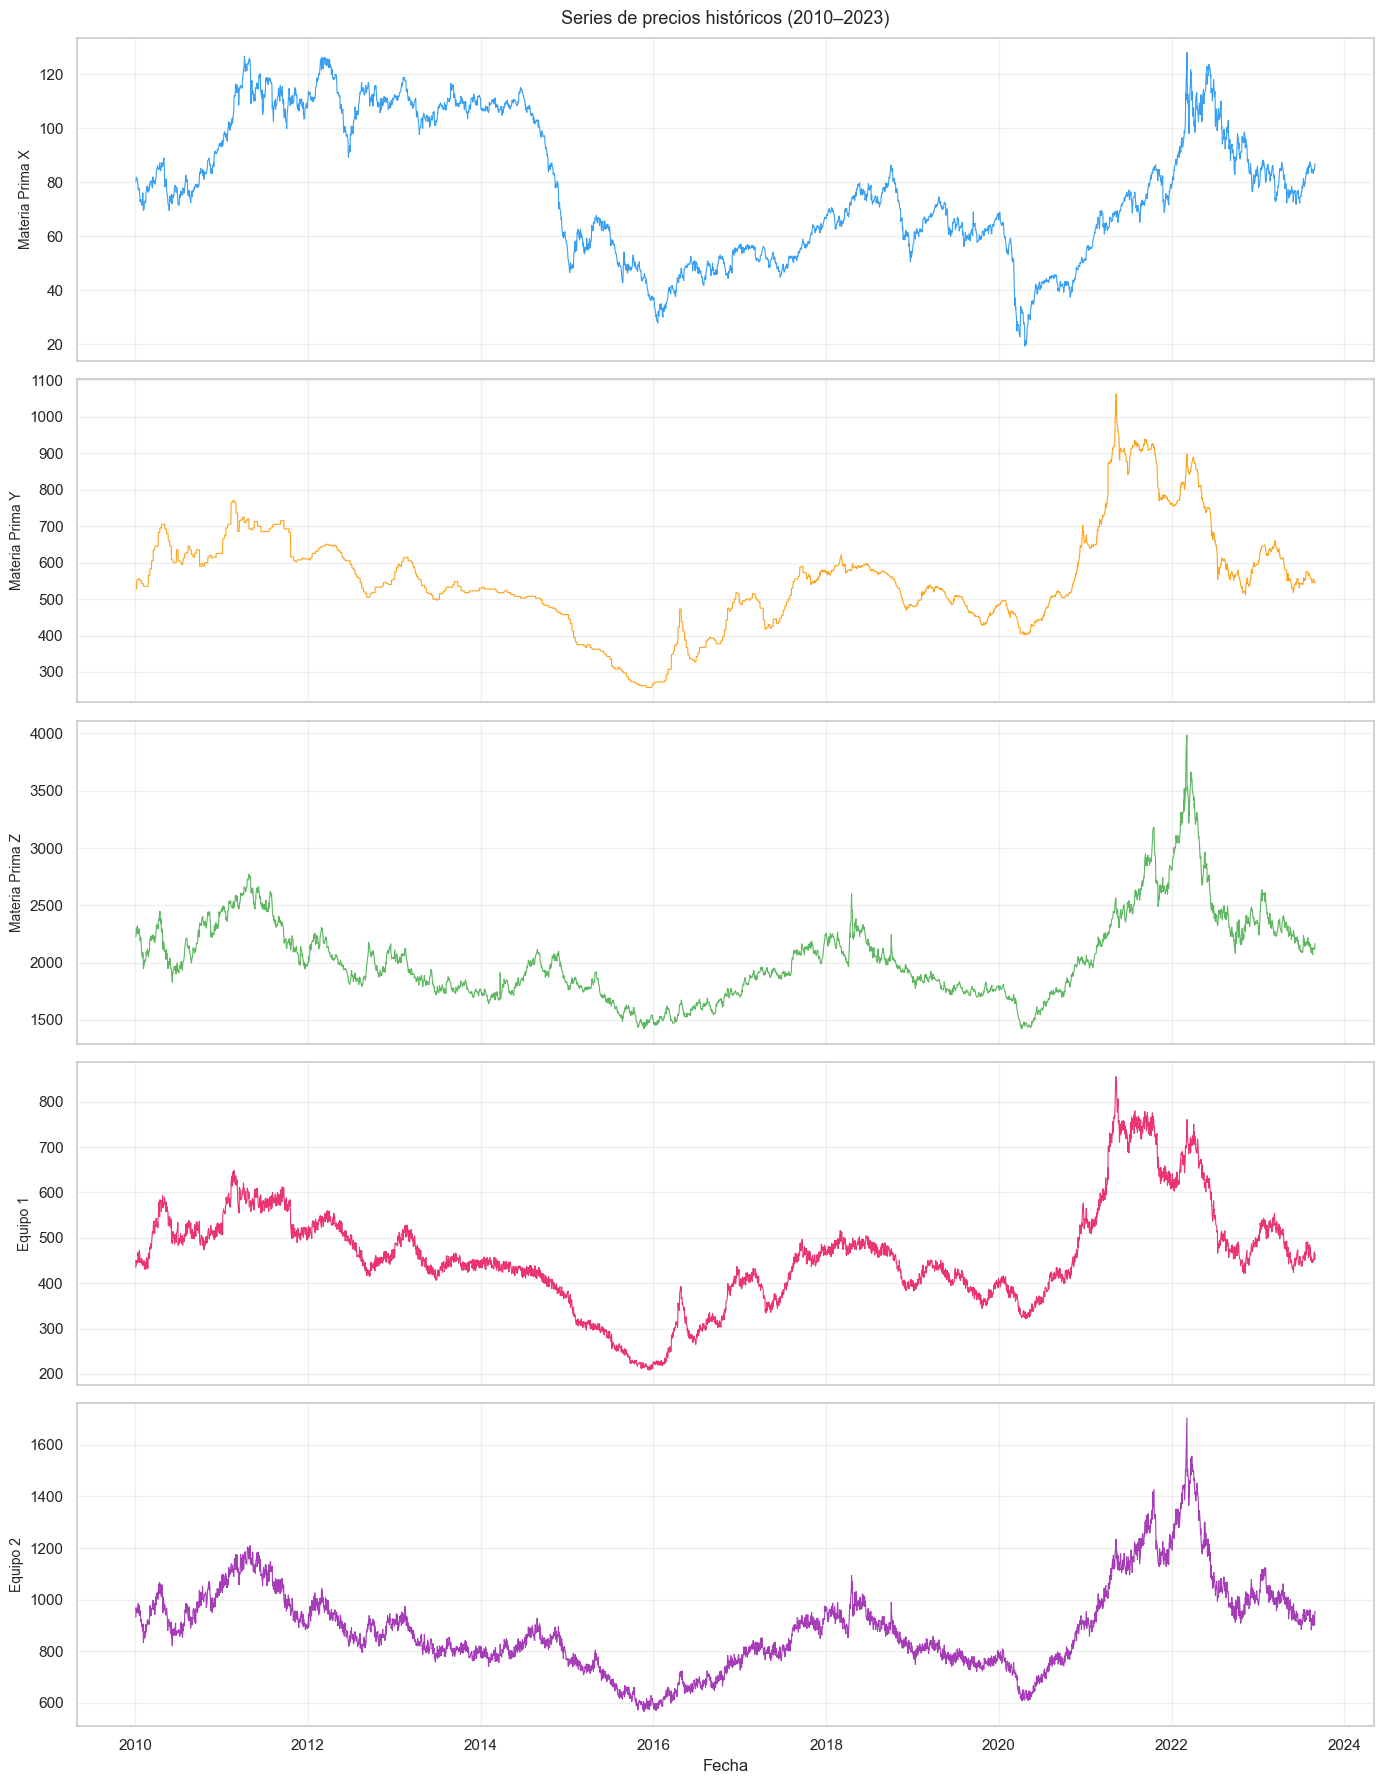

In [10]:
variables = {
    'Price_X': ('Materia Prima X', '#2196F3'),
    'Price_Y': ('Materia Prima Y', '#FF9800'),
    'Price_Z': ('Materia Prima Z', '#4CAF50'),
    'Price_Equipo1': ('Equipo 1', '#E91E63'),
    'Price_Equipo2': ('Equipo 2', '#9C27B0'),
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for ax, (col, (label, color)) in zip(axes, variables.items()):
    ax.plot(df['Date'], df[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, alpha=0.3)

axes[0].set_title('Series de precios históricos (2010–2023)', fontsize=13, pad=10)
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/01_series_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis de la distribución de variables

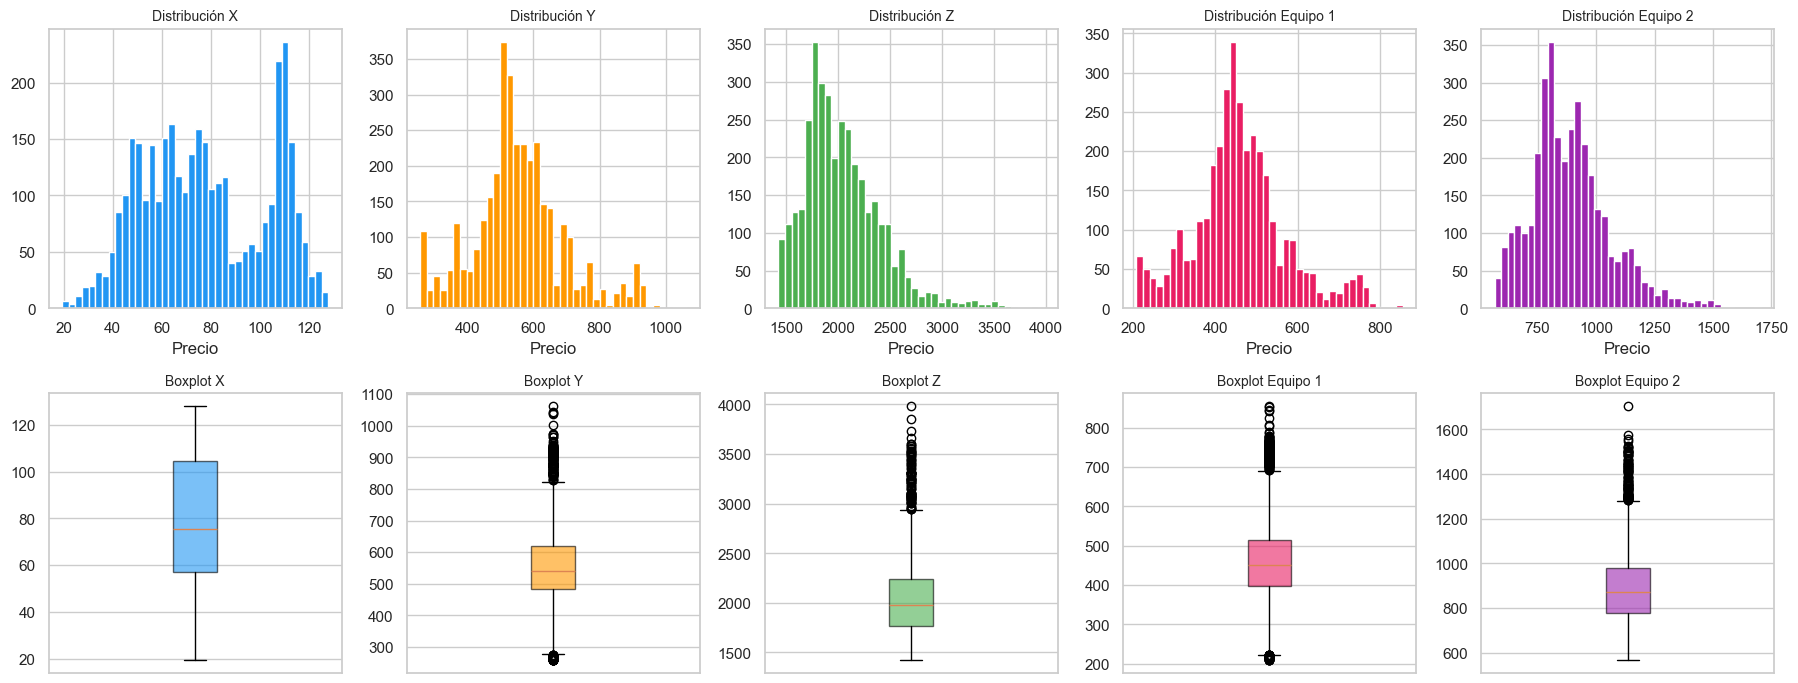

In [11]:
cols = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']
labels = ['X', 'Y', 'Z', 'Equipo 1', 'Equipo 2']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, (col, label) in enumerate(zip(cols, labels)):
    # Histograma
    axes[0, i].hist(df[col], bins=40, edgecolor='white', color=list(variables.values())[i][1])
    axes[0, i].set_title(f'Distribución {label}', fontsize=10)
    axes[0, i].set_xlabel('Precio')
    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor=list(variables.values())[i][1], alpha=0.6))
    axes[1, i].set_title(f'Boxplot {label}', fontsize=10)
    axes[1, i].set_xticks([])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/02_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Matriz de correlación

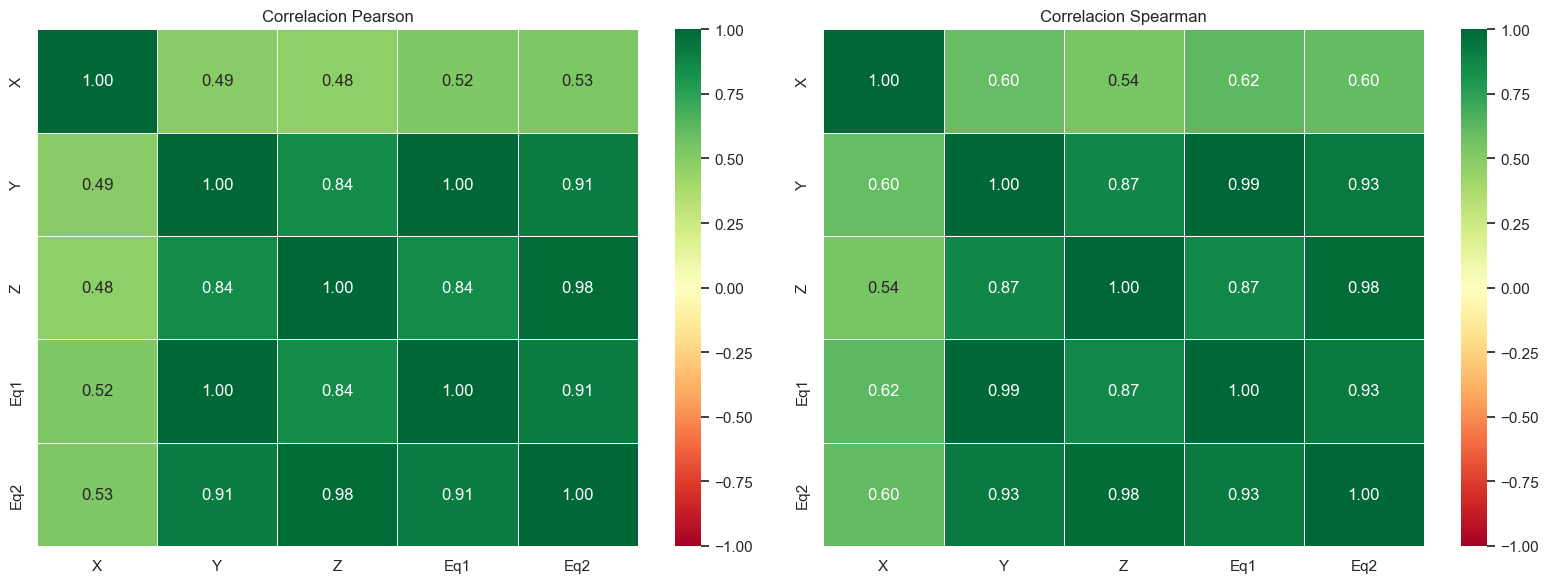


Correlacion de Pearson con Equipo1 y Equipo2:
         Price_Equipo1  Price_Equipo2
Price_X          0.523          0.530
Price_Y          0.997          0.913
Price_Z          0.844          0.983


In [12]:
corr_matrix = df[cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = df[cols].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, center=0,
        xticklabels=['X', 'Y', 'Z', 'Eq1', 'Eq2'],
        yticklabels=['X', 'Y', 'Z', 'Eq1', 'Eq2'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'Correlacion {method.capitalize()}', fontsize=12)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/03_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelacion de Pearson con Equipo1 y Equipo2:")
print(corr_matrix[['Price_Equipo1', 'Price_Equipo2']].iloc[:3].round(3))

## 5. Análisis de valores atípicos (IQR)

In [13]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

print("Valores atipicos por variable (metodo IQR, k=1.5):")
for col in cols:
    outliers = detect_outliers_iqr(df[col])
    pct = outliers.mean() * 100
    print(f"  {col:18s}: {outliers.sum():4d} registros ({pct:.1f}%)")

Valores atipicos por variable (metodo IQR, k=1.5):
  Price_X           :    0 registros (0.0%)
  Price_Y           :  291 registros (8.2%)
  Price_Z           :   90 registros (2.5%)
  Price_Equipo1     :  223 registros (6.3%)
  Price_Equipo2     :  105 registros (3.0%)


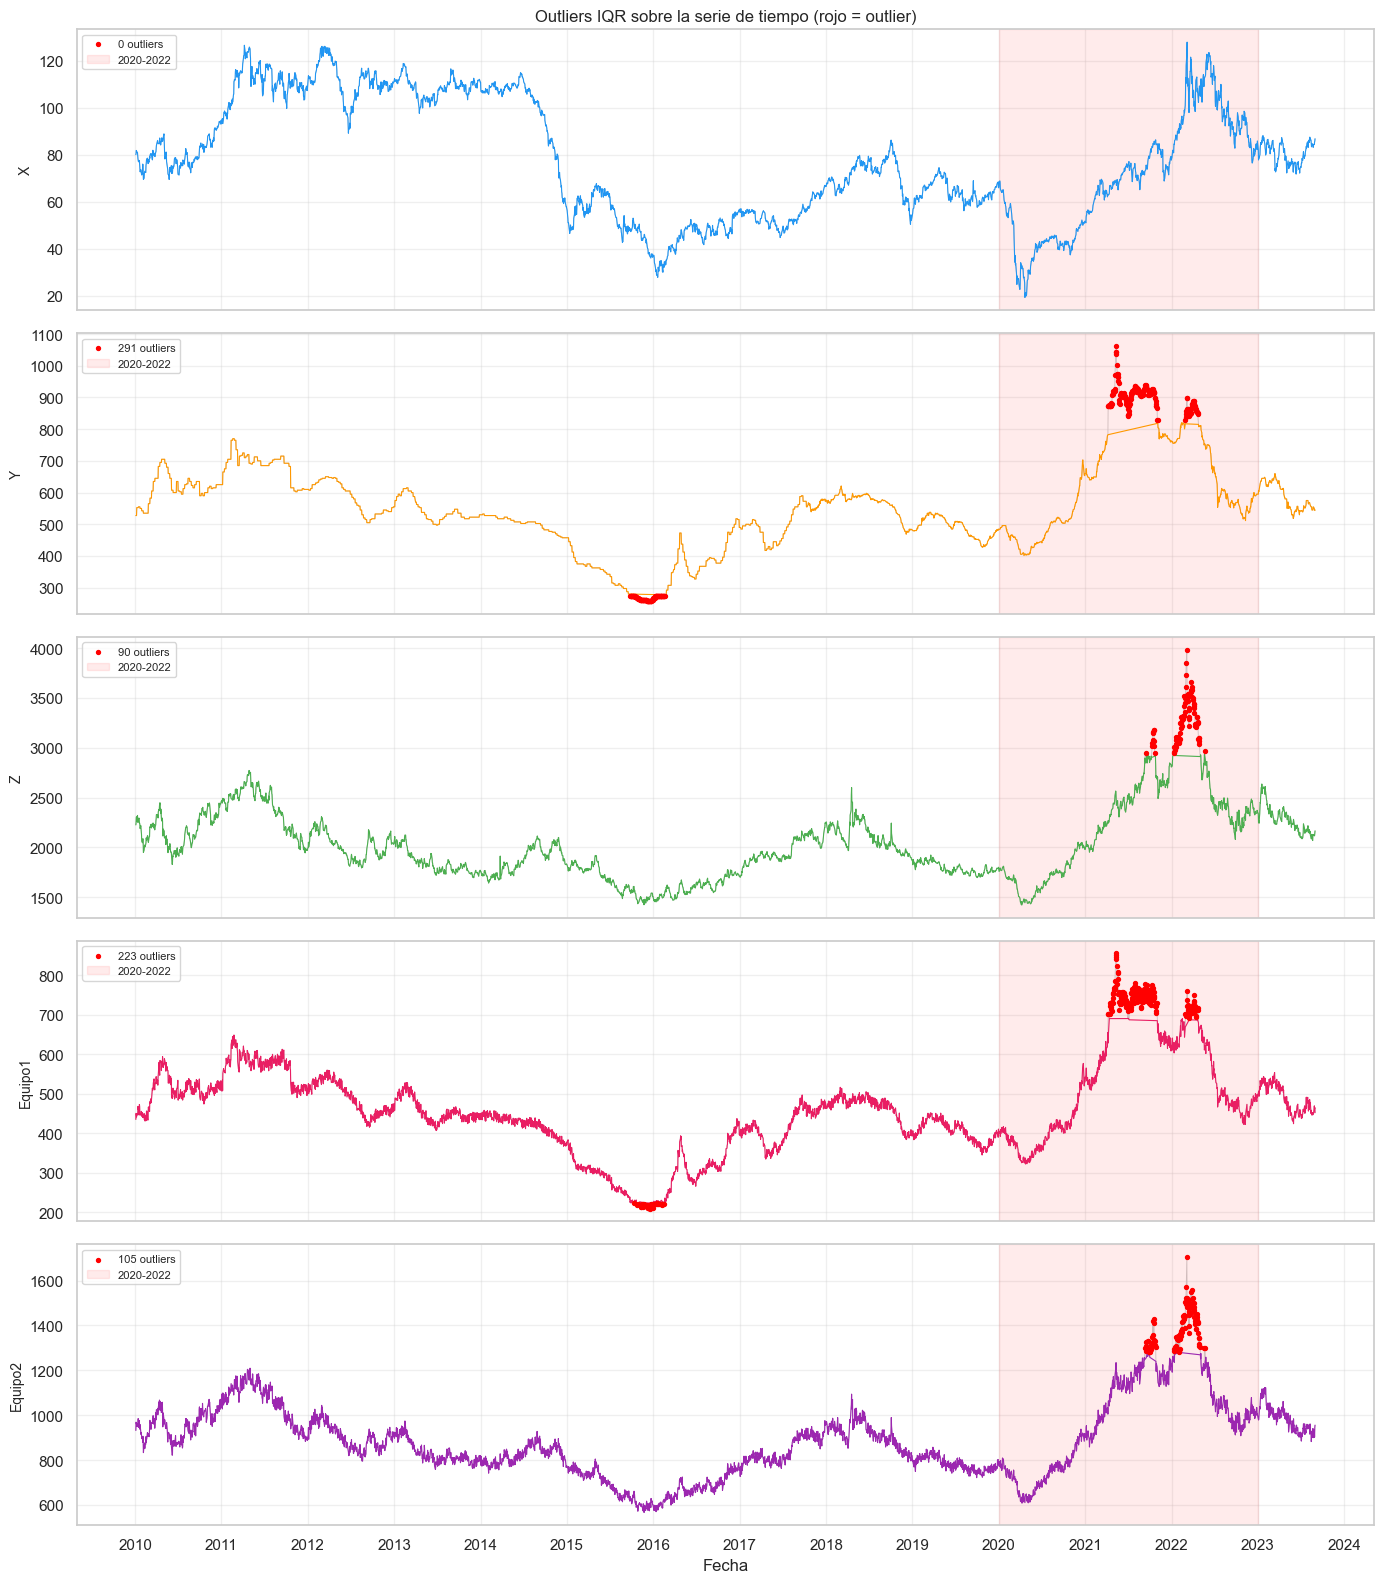

Outliers dentro vs fuera del periodo 2020-2022:
-------------------------------------------------------
Price_X           :   0 outliers
Price_Y           : 291 outliers | 188 en 2020-2022 (65%) | 103 fuera
Price_Z           :  90 outliers |  90 en 2020-2022 (100%) |   0 fuera
Price_Equipo1     : 223 outliers | 177 en 2020-2022 (79%) |  46 fuera
Price_Equipo2     : 105 outliers | 105 en 2020-2022 (100%) |   0 fuera


In [21]:
# Marcar outliers por variable y visualizar su distribucion en el tiempo
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

for ax, col, color in zip(axes, cols, colors):
    outlier_mask = detect_outliers_iqr(df[col])

    # Serie completa en gris tenue
    ax.plot(df["Date"], df[col], color="#cccccc", linewidth=0.6, zorder=1)

    # Serie sin outliers en color
    ax.plot(df.loc[~outlier_mask, "Date"], df.loc[~outlier_mask, col],
            color=color, linewidth=0.8, zorder=2)

    # Outliers como puntos rojos
    ax.scatter(df.loc[outlier_mask, "Date"], df.loc[outlier_mask, col],
               color="red", s=8, zorder=3, label=f"{outlier_mask.sum()} outliers")

    # Banda de referencia COVID / inflacion
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2022-12-31"),
               alpha=0.08, color="red", label="2020-2022")

    ax.set_ylabel(col.replace("Price_", ""), fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))

axes[0].set_title("Outliers IQR sobre la serie de tiempo (rojo = outlier)", fontsize=12)
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/06_outliers_tiempo.png", dpi=150, bbox_inches="tight")
plt.show()

# Porcentaje de outliers dentro y fuera del periodo 2020-2022
print("Outliers dentro vs fuera del periodo 2020-2022:")
print(f"{"-"*55}")
mascara_covid = (df["Date"] >= "2020-01-01") & (df["Date"] <= "2022-12-31")
for col in cols:
    outlier_mask = detect_outliers_iqr(df[col])
    dentro  = (outlier_mask & mascara_covid).sum()
    fuera   = (outlier_mask & ~mascara_covid).sum()
    total   = outlier_mask.sum()
    if total > 0:
        pct_dentro = dentro / total * 100
        print(f"{col:18s}: {total:3d} outliers | {dentro:3d} en 2020-2022 ({pct_dentro:.0f}%) | {fuera:3d} fuera")
    else:
        print(f"{col:18s}:   0 outliers")


## 6. Análisis de variabilidad por año

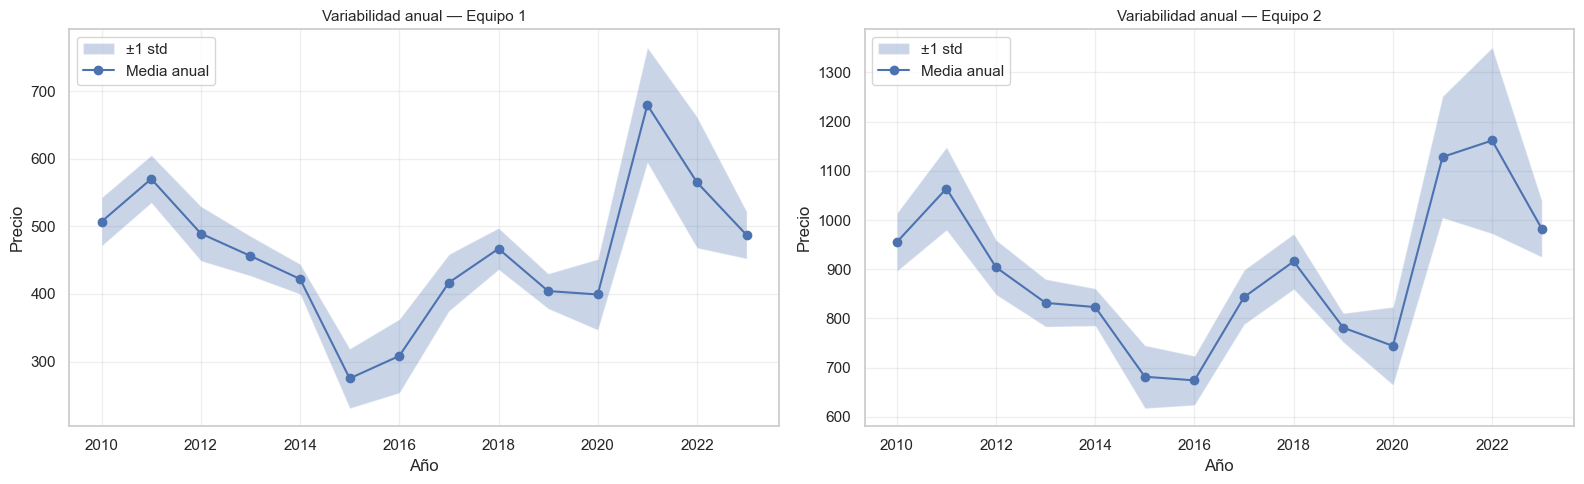

In [14]:
df['year'] = df['Date'].dt.year
yearly_std = df.groupby('year')[cols].std().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, target, label in zip(axes, ['Price_Equipo1', 'Price_Equipo2'], ['Equipo 1', 'Equipo 2']):
    yearly_stats = df.groupby('year')[target].agg(['mean', 'std'])
    ax.fill_between(yearly_stats.index,
                    yearly_stats['mean'] - yearly_stats['std'],
                    yearly_stats['mean'] + yearly_stats['std'],
                    alpha=0.3, label='±1 std')
    ax.plot(yearly_stats.index, yearly_stats['mean'], marker='o', label='Media anual')
    ax.set_title(f'Variabilidad anual — {label}', fontsize=11)
    ax.set_xlabel('Año')
    ax.set_ylabel('Precio')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_variabilidad_anual.png', dpi=150, bbox_inches='tight')
plt.show()

df = df.drop(columns='year')

## 7. Scatter plots: materias primas vs equipos

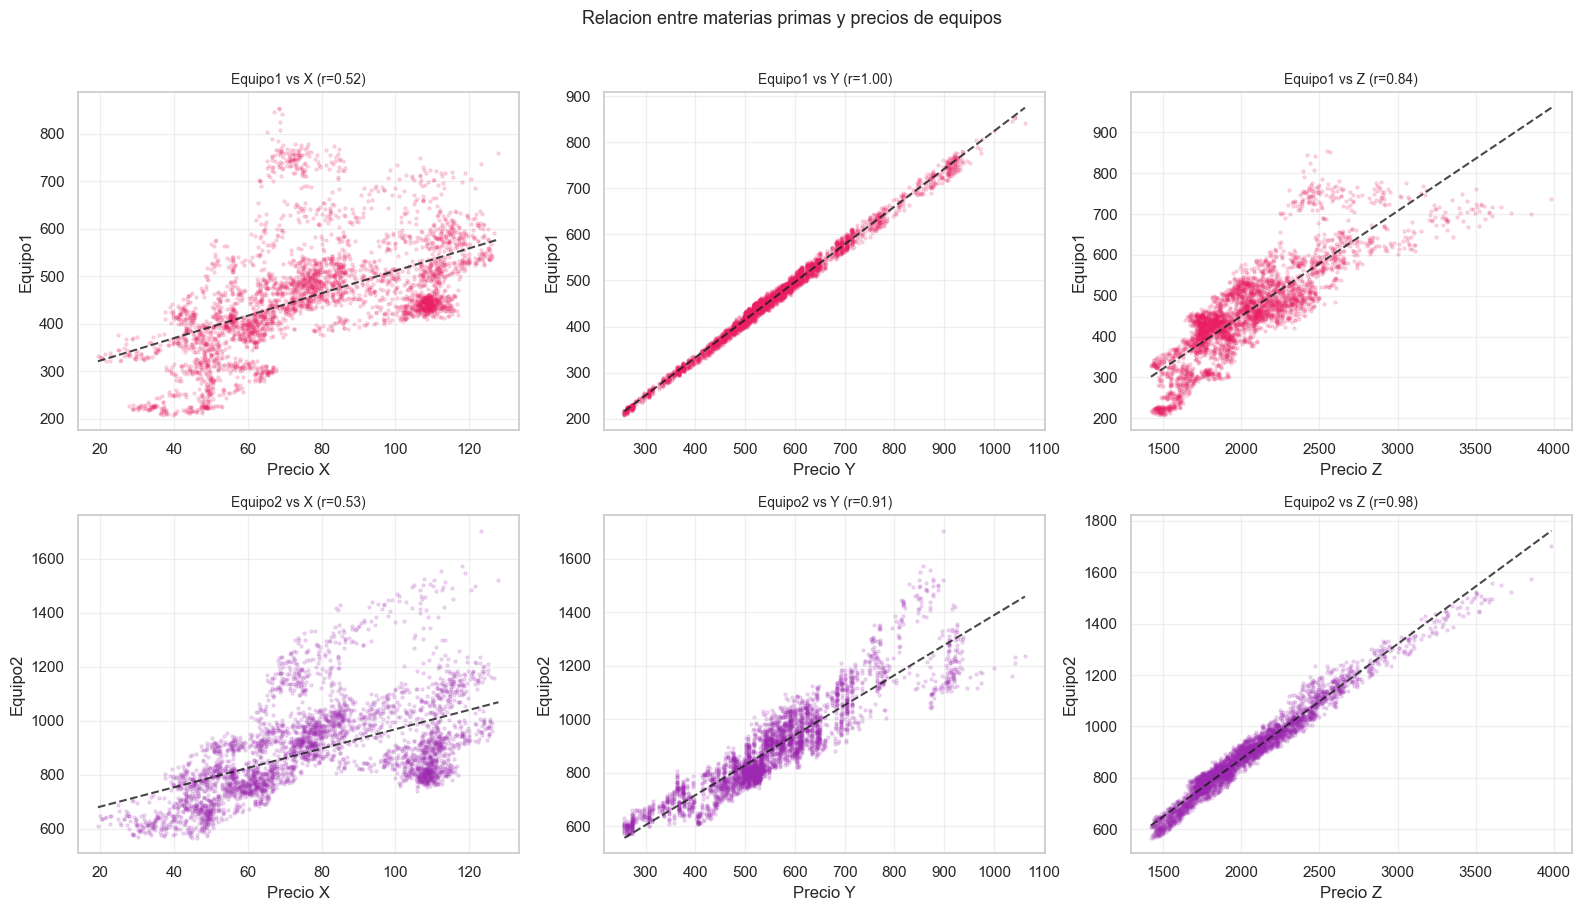

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

targets = ['Price_Equipo1', 'Price_Equipo2']
features = ['Price_X', 'Price_Y', 'Price_Z']
feature_labels = ['X', 'Y', 'Z']
colors_eq = ['#E91E63', '#9C27B0']

for row, (target, color) in enumerate(zip(targets, colors_eq)):
    for col_idx, (feat, flabel) in enumerate(zip(features, feature_labels)):
        ax = axes[row, col_idx]
        ax.scatter(df[feat], df[target], alpha=0.15, s=5, color=color)
        # Línea de tendencia
        z = np.polyfit(df[feat], df[target], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, alpha=0.8)
        r = df[[feat, target]].corr().iloc[0, 1]
        ax.set_title(f'{target.replace("Price_","")} vs {flabel} (r={r:.2f})', fontsize=10)
        ax.set_xlabel(f'Precio {flabel}')
        ax.set_ylabel(target.replace('Price_', ''))
        ax.grid(True, alpha=0.3)

plt.suptitle('Relacion entre materias primas y precios de equipos', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Hallazgos

* Contamos con un total de 3530 registros diarios (dìas habiles), sin valoresn ulos ni duplicados, se encontraron 34 dìas habiles faltantes, sin embargo estas correspondian a 29 dìas festivos de acuerdo al calendario Colombiano + 5 fechas por fiestas decembrinas.

* Encontramos correlaciones altas entre algunas variables:
    * Corr y,Equipo_1 = 0.997 Casi perfecta
    * Corr Z, equipo_2= 0,983 Casi perfecta
    * Corr Z, equipo_1 = 0.844 y Corr Y, equipo_2 0.913 Correlaciones altas
    * Corr Y,Z 0.84 correlaciòn fuerte, lo cual indica que estas dos variables no pueden entrar juntas al modleo porque generarian problemas de multicolinealidad.

Las correlaciones fuertes entre Y y equipo 1 y Z y equipo_2, pueden ser espurias, es decir, dos variables crecen juntas por tendencia, sin causalidad real. Esto lo podemos confirmar o descartar en los siguientes pasos.

* Los outliers encontrados, pueden deberse al choque por Covid o inflación, son outliers reales y no errores en los datos. En 2020 se observa que los precios cayeron debido a la pandemia y entre 2021 y 2022 los precios se dispararon puedo ser debido a la inflación, paros o escacez de materiales. X es la variable más estable del dataset ya que no presenta outliers.